# Setting up the notebook and realtive paths

In [1]:
# Discover repo root and read all CSV files from the per-series folders
from pathlib import Path
import pandas as pd
import sys

# Find repo root
repo_root = Path.cwd()
for candidate in [repo_root] + list(repo_root.parents):
    if (candidate / 'pyproject.toml').exists() or (candidate / '.git').exists():
        repo_root = candidate
        break

# Add repo root to sys.path FIRST (before importing from functions)
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

# Now import validation functions
from functions.validation_functions import (
    remove_duplicate_and_fill_missing,
)

# Find repo root (stop at folder containing pyproject.toml or .git)
repo_root = Path.cwd()
for candidate in [repo_root] + list(repo_root.parents):
    if (candidate / 'pyproject.toml').exists() or (candidate / '.git').exists():
        repo_root = candidate
        break
print('Repo root:', repo_root)

wiertsema_dir = repo_root / 'output_data' / 'only_csv_wiertsema'
fugro_dir = repo_root / 'output_data' / 'only_csv_fugro'
# Directory containing meteorological/stressor CSVs
stressor_dir = repo_root / 'input_stressors'
# Explicit stressor file paths used elsewhere in notebooks
precip_path = stressor_dir / 'knmi_berkhout_hourly_rain.csv'
evap_path = stressor_dir / 'knmi_berkhout_hourly_makkink.csv'

out_fig = repo_root / 'output_data' / 'figures'
out_fig.mkdir(parents=True, exist_ok=True)

print('wiertsema_dir ->', wiertsema_dir)
print('fugro_dir    ->', fugro_dir)
print('precip_path ->', precip_path)
print('evap_path  ->', evap_path)

Repo root: d:\Users\jvanruitenbeek\data_validation
wiertsema_dir -> d:\Users\jvanruitenbeek\data_validation\output_data\only_csv_wiertsema
fugro_dir    -> d:\Users\jvanruitenbeek\data_validation\output_data\only_csv_fugro
precip_path -> d:\Users\jvanruitenbeek\data_validation\input_stressors\knmi_berkhout_hourly_rain.csv
evap_path  -> d:\Users\jvanruitenbeek\data_validation\input_stressors\knmi_berkhout_hourly_makkink.csv


# Loading in the precipitation and evap file

Based on data with the "." seperator

For different dataset based on hourly data with the ";" and "," seperators

In [2]:
df_prec_mm = (
    pd.read_csv(
        precip_path,
        sep=",",                           # comma-delimited file
        decimal=".",                       # dot as decimal separator (e.g., 0.3)
        index_col=0,                       # first column ('timestamp;') as index
        parse_dates=[0],                   # parse first column as datetime
        # date_format="%Y-%m-%d %H:%M:%S", # optional: faster & stricter
        encoding="utf-8-sig",
        encoding_errors="replace",
    )
    if precip_path.exists() else None
)


df_evap = (
    pd.read_csv(
        evap_path,
        sep=",",                           # comma-delimited file
        decimal=".",                       # dot as decimal separator (e.g., 0.3)
        index_col=0,                       # first column ('timestamp;') as index
        parse_dates=[0],                   # parse first column as datetime
        # date_format="%Y-%m-%d %H:%M:%S", # optional: faster & stricter
        encoding="utf-8-sig",
        encoding_errors="replace",
    )
    if evap_path.exists() else None
)

In [3]:
df_prec_mm

,Precipitation
timestamp;,
2021-01-01 00:00:00,0.0
2021-01-01 01:00:00,0.0
2021-01-01 02:00:00,0.0
2021-01-01 03:00:00,0.0
2021-01-01 04:00:00,0.0
...,...
2025-12-01 19:00:00,0.0
2025-12-01 20:00:00,0.0
2025-12-01 21:00:00,0.0


<Axes: xlabel='timestamp'>

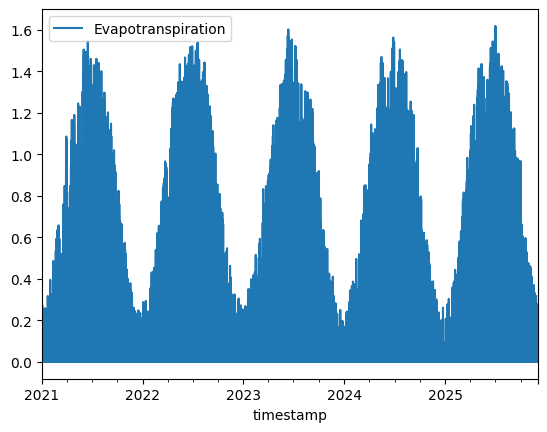

In [4]:
df_evap.plot()

# Function to create the .csv files

In [5]:
# Configuration: Choose which dataset to process
# Options: 'fugro' or 'wiertsema'
dataset_choice = 'wiertsema'

# Set input and output directories based on choice
if dataset_choice.lower() == 'fugro':
    input_dir = repo_root / "output_data" / "only_csv_fugro"
    output_dir = repo_root / "output_data" / "csv_fugro_knmi"
    print("Selected: FUGRO validated dataset")
elif dataset_choice.lower() == 'wiertsema':
    input_dir = repo_root / "output_data" / "only_csv_wiertsema"
    output_dir = repo_root / "output_data" / "csv_wiertsema_knmi"
    print("Selected: WIERTSEMA validated dataset")
else:
    raise ValueError("dataset_choice must be 'fugro' or 'wiertsema'")

# Create output directory if it doesn't exist
output_dir.mkdir(parents=True, exist_ok=True)

print(f"Input directory:  {input_dir}")
print(f"Output directory: {output_dir}\n")

# Get all CSV files
csv_files = sorted(input_dir.glob("*.csv"))
print(f"Found {len(csv_files)} validated CSV files to process\n")

Selected: WIERTSEMA validated dataset
Input directory:  d:\Users\jvanruitenbeek\data_validation\output_data\only_csv_wiertsema
Output directory: d:\Users\jvanruitenbeek\data_validation\output_data\csv_wiertsema_knmi

Found 302 validated CSV files to process



In [6]:
# Process each file
results = []
failed_files = []

for i, file_path in enumerate(csv_files, start=1):
    try:
        print(f"[{i}/{len(csv_files)}] Processing: {file_path.name}")
        
        # Loading in the validated CSV
        validated_df = pd.read_csv(
            file_path,
            index_col=0,
            parse_dates=True,
            encoding="utf-8-sig",
            encoding_errors="replace"
        )

        # # Bugfix statement
        # validated_df["Time"] = validated_df.index
        # validated_df.index.name = None

        # # Print statement
        print(validated_df.info())

        # Step 1: Remove duplicates
        validated_df, _ = remove_duplicate_and_fill_missing(validated_df)
        
        # Align precipitation and evaporation to the validated data's index
        ref_index = validated_df.index
        prec_aligned = df_prec_mm.reindex(ref_index)
        evap_aligned = df_evap.reindex(ref_index)
        
        # Add precipitation and evapotranspiration columns
        validated_df["Precipitation"] = prec_aligned.iloc[:, 0].values
        validated_df["Evapotranspiration"] = evap_aligned.iloc[:, 0].values
        
        # Calculate recharge (Precipitation - Evapotranspiration)
        validated_df["recharge"] = validated_df["Precipitation"] - validated_df["Evapotranspiration"]

        # 7. Reorder Columns: Ensure 'v0' is the last column
        all_cols = validated_df.columns.tolist()
        if 'v0' in all_cols:
            all_cols.remove('v0')
            final_col_order = all_cols + ['v0']
            validated_df = validated_df[final_col_order]
        
        # Save to output
        output_file = output_dir / f"{file_path.stem}.csv"
        validated_df.to_csv(output_file, encoding="utf-8-sig")
        
        print(f"  ✓ Saved: {output_file.name}")
        print(f"    Final columns: {list(validated_df.columns)}\n")
        
        results.append({
            'Filename': file_path.name,
            'Status': '✓',
            'Rows': len(validated_df),
            'Columns': len(validated_df.columns)
        })
        
    except Exception as e:
        print(f"  ✗ Error: {str(e)}\n")
        failed_files.append(file_path.name)
        results.append({
            'Filename': file_path.name,
            'Status': '✗',
            'Rows': 0,
            'Columns': 0
        })

# Summary
print("="*70)
print("PROCESSING COMPLETE")
print("="*70)
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))
print(f"\nSuccessful: {len(results_df[results_df['Status'] == '✓'])}/{len(csv_files)}")
if failed_files:
    print(f"Failed: {len(failed_files)}")
    for fname in failed_files[:10]:
        print(f"  - {fname}")
    if len(failed_files) > 10:
        print(f"  ... and {len(failed_files) - 10} more")

print(f"\n✓ All processed CSVs saved to: {output_dir}")

[1/302] Processing: 83034-1 HB001PB01 BE0049+00_BUKR_GMW_PB1_F-229.csv
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3762 entries, 2025-06-24 22:00:00 to 2025-11-30 00:00:00
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   head    3762 non-null   float64
dtypes: float64(1)
memory usage: 58.8 KB
None
  ✓ Saved: 83034-1 HB001PB01 BE0049+00_BUKR_GMW_PB1_F-229.csv
    Final columns: ['head', 'head_raw', 'Precipitation', 'Evapotranspiration', 'recharge', 'v0']

[2/302] Processing: 83034-1 HB002PB01 BE0049+00_BIKR_GMW_PB1_F-227.csv
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3217 entries, 2025-07-16 14:00:00 to 2025-11-30 00:00:00
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   head    3217 non-null   float64
dtypes: float64(1)
memory usage: 50.3 KB
None
  ✓ Saved: 83034-1 HB002PB01 BE0049+00_BIKR_GMW_PB1_F-227.csv
    Final columns: ['head', 'head_raw'